<a href="https://colab.research.google.com/github/xcsilverio7/soccerTransfers/blob/main/soccerTransfers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Soccer Transfer Dataset**

I am an avid sports fan, and I have always been fascinated by transfer fees of soccer players. This Colab Notebook explores a dataset from Kaggle regarding the record transfers in European soccer.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/transferFees/record_transfers.csv")

Mounted at /content/drive


In [ ]:
#Gathering important info on dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transfer_id       57 non-null     object 
 1   date              57 non-null     object 
 2   year              57 non-null     int64  
 3   season            57 non-null     object 
 4   player_name       57 non-null     object 
 5   position          57 non-null     object 
 6   age_at_transfer   57 non-null     int64  
 7   from_club         57 non-null     object 
 8   to_club           57 non-null     object 
 9   fee_eur_m         57 non-null     float64
 10  is_free_transfer  57 non-null     int64  
 11  is_loan           57 non-null     int64  
 12  is_extension      57 non-null     int64  
dtypes: float64(1), int64(5), object(7)
memory usage: 5.9+ KB


**Question 1: Did the Neymar transfer increase the average transfer fee for a player?**

Neymar's 222 million euro transfer from Barcelona to PSG still remains to be the most expensive transfer in soccer history. I am curious as to whether the fee increased the average transfer fee.

In [ ]:
# Filter for years strictly after 2017 and calculate the mean fee
avg_fee_after = df[df['year'] > 2017]['fee_eur_m'].mean()
print("Average transfer fee after 2017:", avg_fee_after)

Average transfer fee after 2017: 64.37708333333333


In [ ]:
# Average transfer fee before 2017 (inclusive or exclusive depending on your design)
avg_before = df[df['year'] < 2017]['fee_eur_m'].mean()


# Average transfer fee after 2017
avg_after = df[df['year'] > 2017]['fee_eur_m'].mean()


print(f"Average Fee Before 2017: €{avg_before:.2f}M")
print(f"Average Fee After 2017:  €{avg_after:.2f}M")

Average Fee Before 2017: €91.83M
Average Fee After 2017:  €64.38M


In [ ]:
# Get the average transfer fee per year
perYear = df.groupby('year')['fee_eur_m'].mean()
perYear

,fee_eur_m
year,
2009,94.000000
2013,100.000000
2014,81.000000
2016,97.500000
2017,179.000000
2018,110.666667
2019,99.700000
2020,80.000000
2021,71.666667


Based on initial analysis, the average transfer fee decreased after 2017.

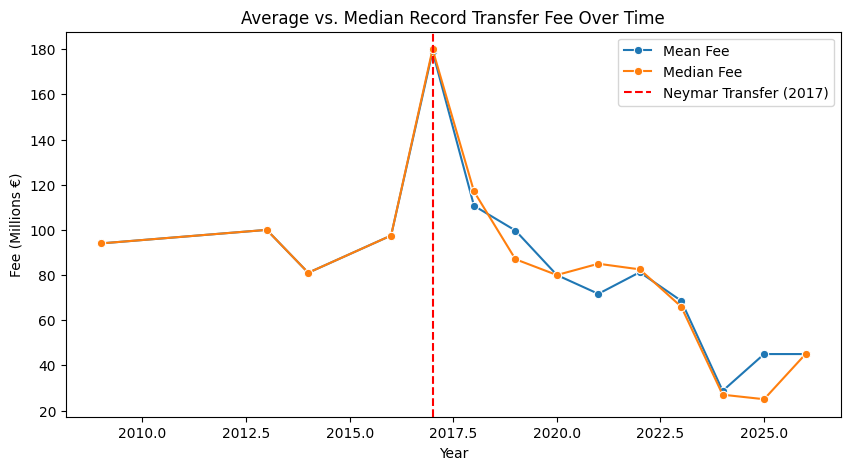

In [ ]:
plt.figure(figsize=(10, 5))
yearly_fees = df.groupby('year')['fee_eur_m'].agg(['mean', 'median']).reset_index()

sns.lineplot(data=yearly_fees, x='year', y='mean', marker='o', label='Mean Fee')
sns.lineplot(data=yearly_fees, x='year', y='median', marker='o', label='Median Fee')

plt.axvline(x=2017, color='red', linestyle='--', label='Neymar Transfer (2017)')
plt.title('Average vs. Median Record Transfer Fee Over Time')
plt.xlabel('Year')
plt.ylabel('Fee (Millions €)')
plt.legend()
plt.show()

This line plot also indicates a decrease in the mean and median transfer fee post-Neymar transfer.

/tmp/ipykernel_1104/3213216470.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='era', y='fee_eur_m', palette='Set2')


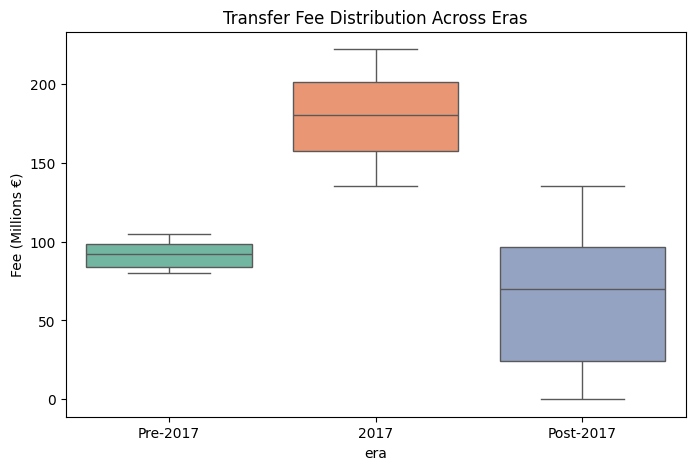

In [ ]:
plt.figure(figsize=(8, 5))
df['era'] = df['year'].apply(lambda x: 'Post-2017' if x > 2017 else ('2017' if x == 2017 else 'Pre-2017'))

sns.boxplot(data=df, x='era', y='fee_eur_m', palette='Set2')
plt.title('Transfer Fee Distribution Across Eras')
plt.ylabel('Fee (Millions €)')
plt.show()

/tmp/ipykernel_1104/2866770813.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='position', y='fee_eur_m', estimator=np.median, ci=None, palette='Blues_d')
/tmp/ipykernel_1104/2866770813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='position', y='fee_eur_m', estimator=np.median, ci=None, palette='Blues_d')


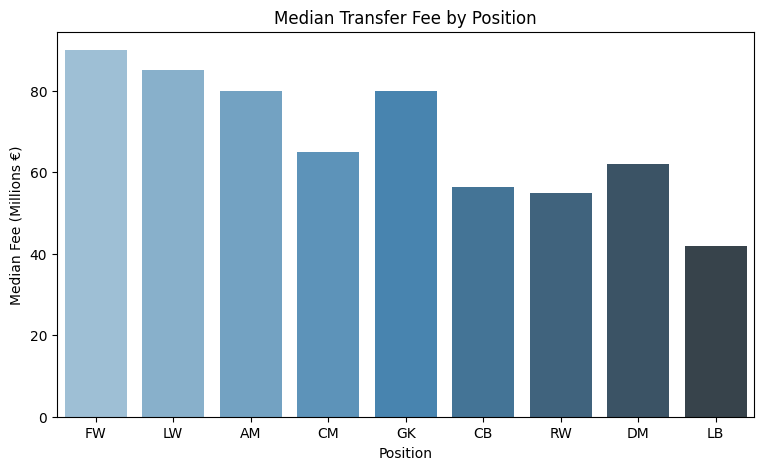

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x='position', y='fee_eur_m', estimator=np.median, ci=None, palette='Blues_d')
plt.title('Median Transfer Fee by Position')
plt.xlabel('Position')
plt.ylabel('Median Fee (Millions €)')
plt.show()

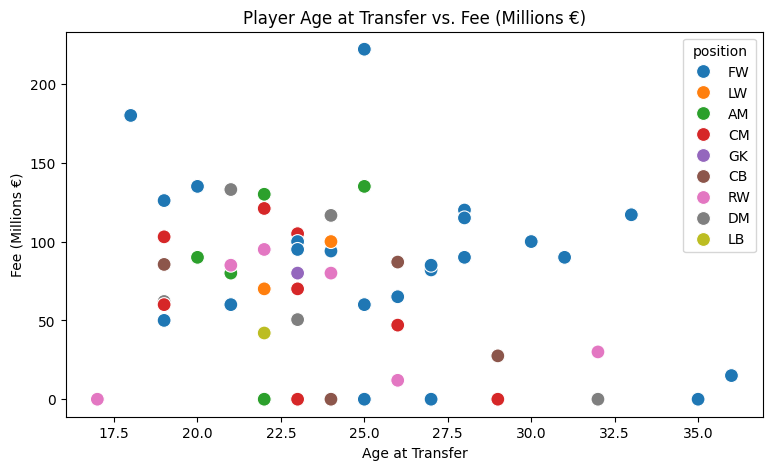

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='age_at_transfer', y='fee_eur_m', hue='position', s=100)
plt.title('Player Age at Transfer vs. Fee (Millions €)')
plt.xlabel('Age at Transfer')
plt.ylabel('Fee (Millions €)')
plt.show()